In [1]:
import numpy as np
import polars as pl
from pathlib import Path

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()

import sys
sys.path.append(str(PROJECT_ROOT))

from src.features.feature_integration import compute_svara_segment_features
from src.io.pitch_io import load_preprocessed_pitch
from src.io.annotation_io import load_annotations
import settings as S

DATA_INTERIM = S.DATA_INTERIM
S.DATA_CORPUS
recording_id = S.SARASUDA_VARNAM[0]
tonic_hz = S.SARASUDA_TONICS[recording_id]

annotation_path = S.DATA_CORPUS / recording_id / "raw" / f"{recording_id}_ann_svara.tsv"

df_pitch = load_preprocessed_pitch(
    recording_id=recording_id,
    root_dir="data/interim",
    tonic_hz=tonic_hz,
    convert_to_cents=True,
)

df_svaras = load_annotations(
    file_path=annotation_path,
    annotation_type="svara",
    engine="polars",
)

df_features_one =compute_svara_segment_features(
    df_pitch = df_pitch,
    df_svaras = df_svaras,
    recording_id = recording_id,
    )

In [2]:
dfs = []

for recording_id in S.SARASUDA_VARNAM:

    tonic_hz = S.SARASUDA_TONICS[recording_id]

    annotation_path = (
        S.DATA_CORPUS
        / recording_id
        / "raw"
        / f"{recording_id}_ann_svara.tsv"
    )

    df_pitch = load_preprocessed_pitch(
        recording_id=recording_id,
        root_dir="data/interim",
        tonic_hz=tonic_hz,
        convert_to_cents=True,
    )

    df_svaras = load_annotations(
        file_path=annotation_path,
        annotation_type="svara",
        engine="polars",
    )

    df_features = compute_svara_segment_features(
        df_pitch=df_pitch,
        df_svaras=df_svaras,
        recording_id=recording_id,
    )

    dfs.append(df_features)

# concatenar tots els recordings
df_features_all = pl.concat(dfs)

print(df_features_all.shape)

(2760, 21)


# Autoencoder baseline

Notebook used to understand the functioning of an autoencoder.

1. Imports
2. Prepare data
3. Define model
4. Training setup
5. Training loop
6. Train model
7. Extract latent embeddings
8. Compute reconstruction error
9. Analyze latent space

## Imports

**NumPy**  
Library for numerical computing and array manipulation.

**PyTorch (`torch`)**  
Main deep learning library used to build and train neural networks.

**torch.nn (`nn`)**  
Provides the basic building blocks for neural networks, such as layers, activation functions, and loss functions.

**TensorDataset / DataLoader**  
Utilities for handling datasets during training.  
- **TensorDataset** groups tensors into a dataset.  
- **DataLoader** creates an iterable over the dataset with batching, shuffling, and efficient loading.

**StandardScaler**  
Preprocessing tool that standardizes features by centering them to mean 0 and scaling to unit variance.

**train_test_split**  
Utility to split arrays or matrices into random training and validation subsets.

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
import numpy as np

selected_features = S.AE_FEATURE_COLUMNS
8
X = df_features_all.select(selected_features).to_numpy()

In [5]:
print("Shape:", X.shape)
print("NaNs:", np.isnan(X).sum())
print("Infs:", np.isinf(X).sum())
print("All finite:", np.isfinite(X).all())

Shape: (2760, 7)
NaNs: 480
Infs: 0
All finite: False


In [6]:
for i, col in enumerate(selected_features):
    n_bad = np.isnan(X[:, i]).sum()
    print(col, n_bad)

duration_sec 68
pitch_median 68
pitch_std 68
pitch_range 68
slope_global 72
d1_std 68
d2_std 68


## Prepare the data

**Input feature matrix `X`**

`X` is the matrix containing the features describing each segment.

Shape:

(n_segments, n_features)

- **n_segments** → number of segments in the dataset  
- **n_features** → number of features describing each segment

Each **row** corresponds to one segment, and each **column** corresponds to one feature.

**StandardScaler**  
Standardizes the input features so that each variable has mean 0 and unit variance.

**fit_transform(X)**  
Learns the scaling parameters from `X` and applies the transformation.

**train_test_split(...)**  
Splits the standardized data into training and validation subsets.

**torch.tensor(..., dtype=torch.float32)**  
Converts the NumPy arrays into PyTorch tensors using 32-bit floating point format.

**TensorDataset(X_train, X_train)**  
Creates a dataset where the input and the target are the same, since an autoencoder reconstructs its own input.

**DataLoader(...)**  
Wraps the dataset into an iterable object for batch-based training.  
- `batch_size=64` means that the model processes 64 samples at a time.  
- `shuffle=True` randomizes the order of training samples at each epoch.

In [7]:


selected_features = [
    "duration_sec",
    "pitch_median",
    "pitch_std",
    "pitch_range",
    "slope_global",
    "d1_std",
    "d2_std",
]

# ---- build X ----
X = df_features_all.select(selected_features).to_numpy()

# remove rows with NaN/inf
mask_valid = np.isfinite(X).all(axis=1)
X = X[mask_valid]

print("Final X shape:", X.shape)


Final X shape: (2688, 7)


In [8]:
# X = your feature array
# shape: (n_segments, n_features)

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, X_val), batch_size=64)

## Autoencoder model

The autoencoder is composed of two parts:

**Encoder**  
Transforms the input feature vector into a lower-dimensional latent representation (the *latent space* or *bottleneck*).

**Decoder**  
Reconstructs the original feature vector from this latent representation.

Architecture:

input_dim → 64 → latent_dim → 64 → input_dim

The model is trained to minimize the **reconstruction error** between the input vector `x` and its reconstruction `x_hat`.

### Implementation

- The model is defined as a class `AE` that inherits from `torch.nn.Module`, the base class for neural network models in PyTorch.

- The constructor `__init__(input_dim, latent_dim=8)` initializes the architecture:
  - `input_dim` → number of features in the input data.
  - `latent_dim` → dimension of the latent space (compression bottleneck).

- `super().__init__()` calls the parent class constructor so that PyTorch can properly register the model parameters.

- The **encoder** and **decoder** are implemented with `nn.Sequential`, which applies layers in order.

#### Encoder

input_dim → Linear → 64 → ReLU → Linear → latent_dim

- `Linear(input_dim, 64)` projects the input feature vector to a hidden layer of size 64.
- `ReLU()` introduces non-linearity.
- `Linear(64, latent_dim)` projects the representation into the latent space.

#### Decoder

latent_dim → Linear → 64 → ReLU → Linear → input_dim

- `Linear(latent_dim, 64)` expands the latent vector.
- `ReLU()` again adds non-linearity.
- `Linear(64, input_dim)` reconstructs the original feature vector.

### Forward pass

The `forward(x)` method defines how data flows through the model:

1. `z = encoder(x)`  
   The input vector is compressed into the latent representation `z`.

2. `x_hat = decoder(z)`  
   The latent vector is decoded to reconstruct the input.

3. The model returns `x_hat`, the reconstructed version of the input.

In [9]:
class AE(nn.Module):

    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## 4. Training setup

This step initializes the components required to train the autoencoder.

### Device

Selects the hardware used for computation.

- `"cuda"` → GPU (if available)  
- `"cpu"` → fallback if no GPU is detected

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### Input dimension

Determines the number of input features.

input_dim = X.shape[1]

Since the feature matrix has shape:

(n_segments, n_features)

`X.shape[1]` corresponds to the number of features per segment.


### Model initialization

Initializes the autoencoder model.

model = AE(input_dim=input_dim, latent_dim=8)

The model is then moved to the selected device (CPU or GPU):

model = model.to(device)


### Optimizer

Defines how the model parameters are updated during training.

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

- `Adam` is a commonly used gradient-based optimizer.
- `model.parameters()` returns the weights that will be updated.
- `lr` (learning rate) controls the update step size.


### Loss function

Defines the objective that the model tries to minimize.

loss_fn = nn.MSELoss()

For an autoencoder, the goal is to minimize the **reconstruction error** between:

x      → input vector  
x_hat  → reconstructed vector

Mean Squared Error (MSE) measures the average squared difference between the two.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X.shape[1]

model = AE(input_dim=input_dim, latent_dim=8).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_fn = nn.MSELoss()

## 5. Training loop

This step defines how the model is trained for one epoch.

The function `run_epoch(...)` can operate in two modes:

- **training mode** → updates the model weights
- **evaluation mode** → computes loss without updating weights

### Function definition

`run_epoch(loader, train=True)`

- `loader` → provides batches of data  
- `train=True` → training mode  
- `train=False` → evaluation mode  

### Initialize loss accumulator

`total_loss = 0`

Stores the accumulated loss over all batches in the epoch.

### Set model mode

`model.train()`  
Enables training behavior.

`model.eval()`  
Disables training behavior.

### Iterate over batches

`for x, y in loader:`

Loops over the dataset batch by batch.

In an autoencoder:

```
x == y
```

because the model tries to reconstruct its own input.

### Move tensors to device

```
x = x.to(device)
y = y.to(device)
```

Moves tensors to CPU or GPU.

### Reset gradients

```
optimizer.zero_grad()
```

Clears gradients from the previous batch.

### Forward pass

```
y_hat = model(x)
```

Produces the reconstructed output.

### Compute loss

```
loss = loss_fn(y_hat, y)
```

Computes reconstruction error between input and output.

### Backpropagation

```
loss.backward()
```

Computes gradients of the loss.

### Parameter update

```
optimizer.step()
```

Updates the model weights.

### Accumulate loss

```
total_loss += loss.item()
```

Adds the batch loss to the epoch loss.

### Return average loss

```
return total_loss / len(loader)
```

Returns the mean loss over the epoch.



In [11]:
def run_epoch(loader, train=True):

    total_loss = 0

    if train:
        model.train()
    else:
        model.eval()

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad()

        y_hat = model(x)
        loss = loss_fn(y_hat, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

## 6. Training the model

This step trains the autoencoder for a fixed number of epochs.

An **epoch** corresponds to one full pass through the training dataset.

At each epoch:

1. The model is trained on the training data.
2. The model is evaluated on the validation data.
3. The training and validation losses are printed.

This allows monitoring whether the model is learning and whether it is overfitting.

### Explanation

`range(50)`  
Runs training for **50 epochs**.

`train_loss = run_epoch(train_loader, train=True)`  
Performs one training epoch and updates the model weights.

`val_loss = run_epoch(val_loader, train=False)`  
Evaluates the model on the validation dataset without updating weights.

`print(...)`  
Displays the training and validation loss for each epoch.
This helps track convergence and detect overfitting.

In [12]:
for epoch in range(50):

    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)

    print(f"{epoch:03d}  train={train_loss:.4f}  val={val_loss:.4f}")

000  train=0.8441  val=0.5833
001  train=0.4560  val=0.3743
002  train=0.3217  val=0.2710
003  train=0.2018  val=0.1350
004  train=0.0960  val=0.0688
005  train=0.0558  val=0.0412
006  train=0.0362  val=0.0320
007  train=0.0298  val=0.0274
008  train=0.0259  val=0.0248
009  train=0.0233  val=0.0222
010  train=0.0213  val=0.0204
011  train=0.0196  val=0.0188
012  train=0.0180  val=0.0175
013  train=0.0167  val=0.0159
014  train=0.0155  val=0.0151
015  train=0.0146  val=0.0136
016  train=0.0135  val=0.0127
017  train=0.0125  val=0.0117
018  train=0.0114  val=0.0103
019  train=0.0105  val=0.0094
020  train=0.0094  val=0.0089
021  train=0.0086  val=0.0077
022  train=0.0079  val=0.0070
023  train=0.0073  val=0.0066
024  train=0.0069  val=0.0065
025  train=0.0065  val=0.0062
026  train=0.0062  val=0.0057
027  train=0.0059  val=0.0057
028  train=0.0057  val=0.0054
029  train=0.0054  val=0.0053
030  train=0.0053  val=0.0052
031  train=0.0051  val=0.0049
032  train=0.0049  val=0.0049
033  train

## 7. Extract latent embeddings

After training the autoencoder, we can obtain the **latent representation** of each segment.

The encoder compresses the input feature vector into a lower-dimensional vector `z`.  
These vectors are called **latent embeddings**.

The result is a matrix:

(n_segments, latent_dim)

Each row corresponds to the latent representation of one segment.

### Explanation

`model.eval()`  
Sets the model to evaluation mode.

`X_tensor = torch.tensor(...)`  
Converts the full dataset into a PyTorch tensor and moves it to the selected device.

`torch.no_grad()`  
Disables gradient computation, which makes inference faster and uses less memory.

`model.encoder(X_tensor)`  
Passes the input data through the encoder to obtain the latent vectors.

`.cpu().numpy()`  
Moves the result back to CPU and converts it into a NumPy array.

`Z`  
Matrix containing the latent representation of all segments:

```
Z.shape = (n_segments, latent_dim)
```

In [13]:
X_scaled = scaler.transform(X)

model.eval()

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    Z = model.encoder(X_tensor).cpu().numpy()

print(Z.shape)

(2688, 8)


## 8. Reconstruction error

After training the autoencoder, we can measure how well the model reconstructs each input vector.

The **reconstruction error** measures the difference between:

- `x` → original input vector  
- `x_hat` → reconstructed vector produced by the autoencoder

A large reconstruction error may indicate that a segment is unusual or difficult for the model to represent.

### Explanation

`model(X_tensor)`  
Passes the dataset through the full autoencoder (encoder + decoder) to produce reconstructed vectors.

`.cpu().numpy()`  
Moves the output to CPU and converts it to a NumPy array.

`X_hat`  
Matrix containing the reconstructed version of each input vector.

```
X_hat.shape = (n_segments, n_features)
```

`(X_scaled - X_hat) ** 2`  
Computes the squared difference between the original and reconstructed features.

`np.mean(..., axis=1)`  
Averages the squared differences across all features for each segment.

The result is a vector:

```
reconstruction_error.shape = (n_segments,)
```

Each value corresponds to the reconstruction error of one segment.

In [14]:
with torch.no_grad():
    X_hat = model(X_tensor).cpu().numpy()

reconstruction_error = np.mean((X_scaled - X_hat) ** 2, axis=1)

## 9. Analysis

After training the autoencoder, we can analyze:

- the **latent representations** `Z`
- the **reconstruction error** for each segment

These quantities can be used to explore the structure of the data.

Typical uses include:

- detecting **unusual segments**
- studying the **structure of the latent space**
- using the latent vectors as **compressed features** for further analysis

The reconstruction error measures how well the model can represent each segment.

Segments with **large reconstruction error** may correspond to rare or atypical patterns.

In [15]:
# segments with highest reconstruction error

idx = np.argsort(reconstruction_error)[-10:]

outliers = X[idx]

print(idx)

[ 427 2289  406 2195  416 2095  619 1151  932 2274]


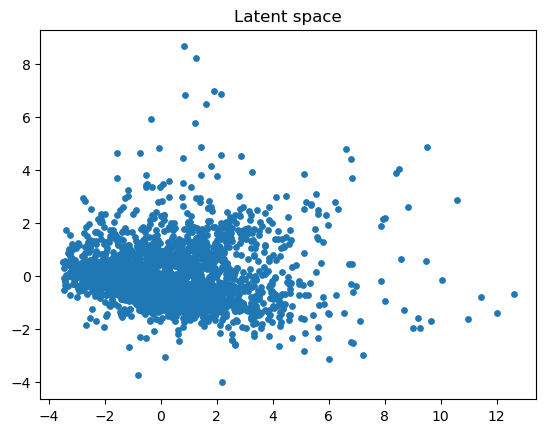

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Z2 = PCA(n_components=2).fit_transform(Z)

plt.scatter(Z2[:,0], Z2[:,1], s=15)
plt.title("Latent space")
plt.show()

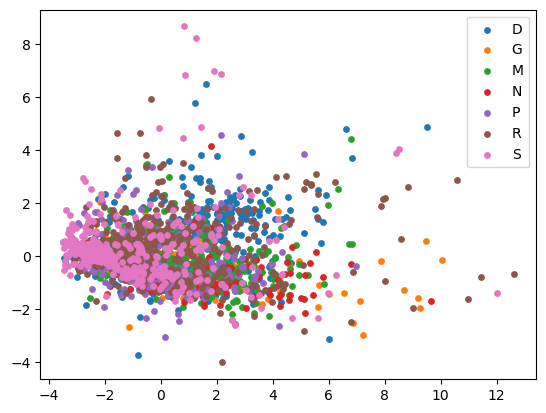

In [17]:
df_meta_valid = df_features_all.filter(pl.Series(mask_valid))
labels = df_meta_valid["svara_label"].to_numpy()

for svara in np.unique(labels):
    mask = labels == svara
    plt.scatter(Z2[mask,0], Z2[mask,1], label=svara, s=15)

plt.legend()
plt.show()

In [18]:

import pandas as pd

df_latent = pd.DataFrame(Z, columns=[f"z{i}" for i in range(Z.shape[1])])
df_feat = df_features_all.select(selected_features).to_pandas()

corr = df_latent.corrwith(df_feat["pitch_range"])
print(corr)

z0   -0.037273
z1    0.062053
z2   -0.035203
z3   -0.012921
z4    0.044786
z5   -0.066377
z6   -0.044977
z7    0.003629
dtype: float64
